In [1]:
!pip install prophet xgboost fastapi uvicorn openpyxl

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Forecasting Case- Study.xlsx to Forecasting Case- Study.xlsx


In [4]:
df = pd.read_excel("Forecasting Case- Study.xlsx")

print(df.head())
print(df.shape)

        State                 Date        Total   Category
0     Alabama  2019-01-12 00:00:00  109574036.0  Beverages
1     Arizona  2019-01-12 00:00:00  109101594.6  Beverages
2    Arkansas  2019-01-12 00:00:00   58049432.2  Beverages
3  California  2019-01-12 00:00:00  444766890.6  Beverages
4    Colorado  2019-01-12 00:00:00   89816716.3  Beverages
(8084, 4)


In [5]:

df['Date'] = pd.to_datetime(df['Date'])

df.rename(columns={
    'Date':'ds',
    'Total':'y'
}, inplace=True)

df.fillna(method='ffill', inplace=True)

print(df.isnull().sum())

State       0
ds          0
y           0
Category    0
dtype: int64


In [6]:
california_df = df[df['State'] == 'California']

print(california_df.head())

          State         ds            y   Category
3    California 2019-01-12  444766890.6  Beverages
46   California 2019-03-11  492597099.4  Beverages
89   California 2019-06-10  506587724.1  Beverages
132  California 2019-08-12  449865324.4  Beverages
175  California 2019-10-11  497063951.7  Beverages


In [7]:
california_df = california_df[['ds','y']]

california_df = california_df.sort_values('ds')

print(california_df.head())

            ds            y
3   2019-01-12  444766890.6
46  2019-03-11  492597099.4
89  2019-06-10  506587724.1
132 2019-08-12  449865324.4
175 2019-10-11  497063951.7


In [8]:
train = california_df[:-56]
test = california_df[-56:]

print(train.shape)
print(test.shape)

(132, 2)
(56, 2)


In [9]:
model = Prophet()

model.fit(train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [10]:
future = model.make_future_dataframe(periods=56)

forecast = model.predict(future)

forecast[['ds','yhat']].tail()

,ds,yhat
183,2022-05-31,8.820287e+08
184,2022-06-01,9.717704e+08
185,2022-06-02,8.588135e+08
186,2022-06-03,8.461336e+08
187,2022-06-04,9.293346e+08


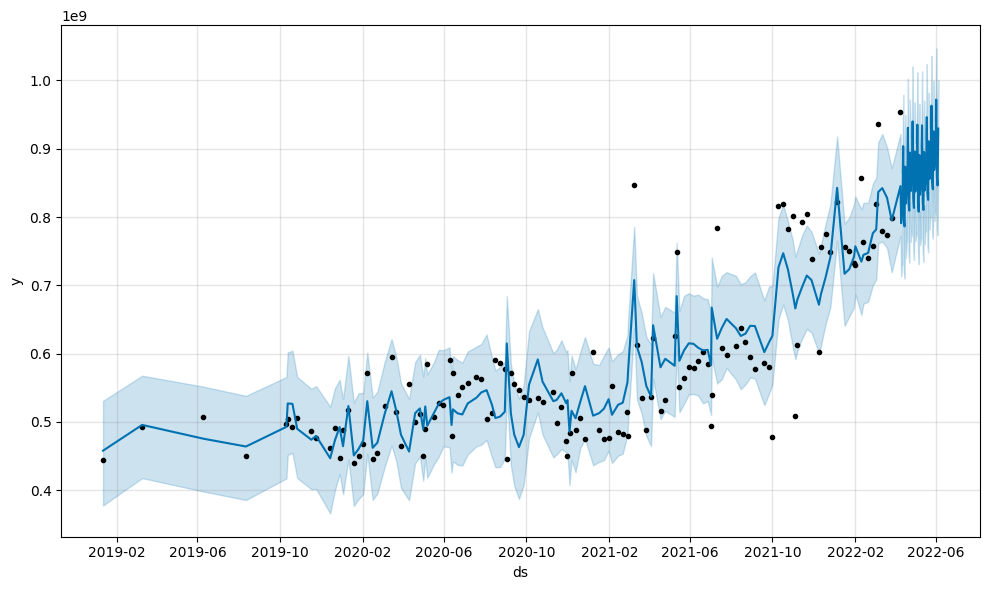

In [11]:
model.plot(forecast)
plt.show()

In [12]:
predictions = forecast[['ds','yhat']].tail(56)

mae = mean_absolute_error(test['y'], predictions['yhat'])

print("MAE:", mae)

MAE: 53826837.74575076


In [13]:
california_df['lag_1'] = california_df['y'].shift(1)

california_df['lag_7'] = california_df['y'].shift(7)

california_df['rolling_mean_7'] = california_df['y'].rolling(7).mean()

california_df['month'] = california_df['ds'].dt.month

california_df['dayofweek'] = california_df['ds'].dt.dayofweek

california_df.dropna(inplace=True)

print(california_df.head())

             ds            y        lag_1        lag_7  rolling_mean_7  month  \
7098 2019-10-27  505768871.6  491957816.8  444766890.6    4.925943e+08     10   
4475 2019-11-17  486794358.5  505768871.6  492597099.4    4.917653e+08     11   
6324 2019-11-24  477240954.9  486794358.5  506587724.1    4.875729e+08     11   
3959 2019-12-15  461461505.5  477240954.9  449865324.4    4.892295e+08     12   
5808 2019-12-22  491464690.1  461461505.5  497063951.7    4.884296e+08     12   

      dayofweek  
7098          6  
4475          6  
6324          6  
3959          6  
5808          6  


In [22]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA model
arima_model = ARIMA(train['y'], order=(5,1,0))
arima_model = arima_model.fit()

# Forecast
arima_forecast = arima_model.forecast(steps=56)

# Evaluation
from sklearn.metrics import mean_absolute_error
mae_arima = mean_absolute_error(test['y'], arima_forecast)

print("ARIMA MAE:", mae_arima)

ARIMA MAE: 48170644.02606481


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be give

In [15]:
from xgboost import XGBRegressor

features = [
    'lag_1',
    'lag_7',
    'rolling_mean_7',
    'month',
    'dayofweek'
]

X = california_df[features]
y = california_df['y']

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)
from xgboost import XGBRegressor

features = [
    'lag_1',
    'lag_7',
    'rolling_mean_7',
    'month',
    'dayofweek'
]

X = california_df[features]
y = california_df['y']

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [16]:
xgb_preds = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, xgb_preds)

print("XGBoost MAE:", mae_xgb)

XGBoost MAE: 46678822.300000004


In [23]:
print("Prophet MAE:", mae)
print("XGBoost MAE:", mae_xgb)
print("ARIMA MAE:", mae_arima)

best_model = min(mae, mae_xgb, mae_arima)

if best_model == mae:
    print("Best Model: Prophet")
elif best_model == mae_xgb:
    print("Best Model: XGBoost")
else:
    print("Best Model: ARIMA")

Prophet MAE: 53826837.74575076
XGBoost MAE: 46678822.300000004
ARIMA MAE: 48170644.02606481
Best Model: XGBoost


In [18]:
predictions.to_csv("forecast_results.csv", index=False)

In [19]:
all_results = []

states = df['State'].unique()

for state in states:

    state_df = df[df['State'] == state][['ds','y']]
    state_df = state_df.sort_values('ds')

    model = Prophet()
    model.fit(state_df)

    future = model.make_future_dataframe(periods=56)
    forecast = model.predict(future)

    result = forecast[['ds','yhat']].tail(56)
    result['State'] = state

    all_results.append(result)

final_forecast = pd.concat(all_results)

print(final_forecast.head())

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


            ds          yhat    State
188 2023-12-04  2.043616e+08  Alabama
189 2023-12-05  2.010457e+08  Alabama
190 2023-12-06  2.203565e+08  Alabama
191 2023-12-07  1.952637e+08  Alabama
192 2023-12-08  1.981129e+08  Alabama


In [20]:
final_forecast.to_csv("all_states_forecast.csv", index=False)

In [21]:
from google.colab import files
files.download("all_states_forecast.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>